# Predict age from fMRI with [`scikit-learn`](https://scikit-learn.org)

We will integrate what we've learned in the previous sections to extract data from a [movie watching based brain development dataset (fMRI)](https://nilearn.github.io/dev/modules/generated/nilearn.datasets.fetch_development_fmri.html) consisting of consists of children (ages 3-13) and young adults (ages 18-39), then feed the data as features to a machine learning model to predict / classify the age group (children vs adult) each subject belongs to.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets
# from nilearn.input_data import NiftiLabelsMasker  <- deprecated in version 0.9
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     cross_validate,
                                     permutation_test_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             classification_report,
                             confusion_matrix)

from IPython.display import clear_output

In [3]:
DATA_DIR = "/Users/jowanglin/brainhack-ntu/machine_learning/nilearn_data"
RANDOM_STATE = 123

### Loading and Fetching the data
- The `data_dir` argument is the path where data should be downloaded.
- By default (if `data_dir=None`), files are downloaded in a `nilearn_data` folder in the <strong>home directory</strong> of the user.
- If the dataset files are already present in the user’s Nilearn data directory, this fetcher will not re-download them. To force a fresh download, you can remove the existing dataset folder from your local Nilearn data directory.

In [ ]:
# Fetch the data
development_dataset = datasets.fetch_development_fmri(data_dir=DATA_DIR,
                                                      reduce_confounds=False)

data = development_dataset.func
confounds = development_dataset.confounds

clear_output()

How many individual subjects do we have?

In [5]:
print(f'length of data = {len(data)}')

length of data = 155


### Get `y` (target labels) and assess its distribution

In [6]:
# Let's load the phenotype data

pheno = pd.DataFrame(development_dataset.phenotypic)
display(pheno.head())

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness
154,sub-pixar155,26.00,Adult,adult,M,R
122,sub-pixar123,27.06,Adult,adult,F,R
123,sub-pixar124,33.44,Adult,adult,M,R
124,sub-pixar125,31.00,Adult,adult,M,R
125,sub-pixar126,19.00,Adult,adult,F,R


Looks like there is a column labeling children and adults. Let's assigned it to a variable.

In [ ]:
y_ageclass = pheno['Child_Adult']  # equivalent to pheno.Child_Adult (see below) in this particular case
                                   # also true for Pandas DataFrames; not true in general for dict-like objects
print(y_ageclass.unique())

<StringArray>
['adult', 'child']
Length: 2, dtype: str


In [8]:
print((pheno['Child_Adult'] == pheno.Child_Adult).all())

True


Let's have a look at the distribution of our target variable

Child_Adult
child    122
adult     33
Name: count, dtype: int64


<Axes: xlabel='Child_Adult', ylabel='count'>

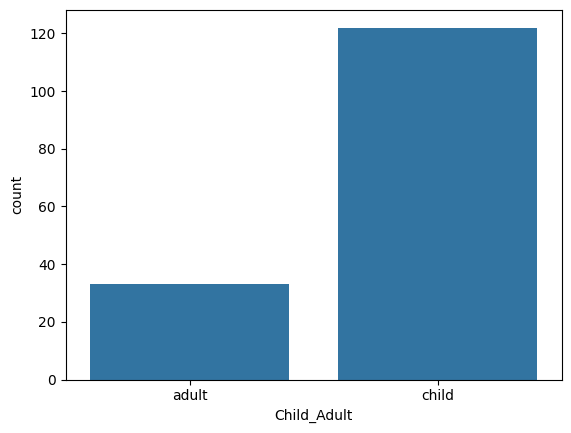

In [9]:
print(pheno['Child_Adult'].value_counts())

sns.countplot(x=y_ageclass)

The dataset is <strong>imbalanced</strong>: there are many more children than adults. This can be a problem because a model may learn to <strong>favor the majority class</strong> and still get a deceptively high accuracy. For example, if most participants are children, a model that predicts "child" too often may look accurate overall while performing poorly on adults. Therefore, accuracy should not be the only performance metric we examine; we should also check metrics such as <i>precision</i> and <i>recall</i> for each class. There are several ways to handle class imbalance. At the model level, for SVC, we can set `class_weight='balanced'`, which gives higher penalty weight to mistakes on the smaller class based on class frequency. Other approaches include changing the decision threshold, calibrating predicted probabilities, undersampling the majority class, or oversampling the minority class. These methods are beyond the scope of this tutorial, so here we will use `class_weight='balanced'` as a simple built-in option.

### Extract features with Nilearn masker

Here, we are going to use the same techniques we learned in the previous tutorial to extract fMRI connectivity features from every subject. Let's reload our atlas, and re-initiate our masker and correlation measure.

In [ ]:
import inspect

# In Jupyter (ipynb environment), you can do the following shortcut, using the question mark:
# datasets.fetch_atlas_basc_multiscale_2015?

# But the "pure Python way" is to call the native function help(), or import inspect and call type() and attribute .__doc__

f = datasets.fetch_atlas_basc_multiscale_2015
print(help(f))  # get both signatire and doc string

print("\n==================================================\n")
print(inspect.signature(f))   # function signature
print(f.__doc__)              # function doc string
print(inspect.getfile(f))     # get file location
print(type(f))                # get type


Help on function fetch_atlas_basc_multiscale_2015 in module nilearn.datasets.atlas:

fetch_atlas_basc_multiscale_2015(data_dir=None, url=None, resume=True, verbose=1, resolution=7, version='sym')
    Download and load multiscale functional brain parcellations.
    
    This :term:`Deterministic atlas` includes group brain parcellations
    generated from resting-state
    :term:`functional magnetic resonance images<fMRI>` from about 200 young
    healthy subjects.
    
    Multiple resolutions (number of networks) are available, among
    7, 12, 20, 36, 64, 122, 197, 325, 444. The brain parcellations
    have been generated using a method called bootstrap analysis of
    stable clusters called as BASC :footcite:t:`Bellec2010`,
    and the resolutions have been selected using a data-driven method
    called MSTEPS :footcite:t:`Bellec2013`.
    
    Note that two versions of the template are available, 'sym' or 'asym'.
    The 'asym' type contains brain images that have been registered i

In [ ]:
# Load atlas
basc = datasets.fetch_atlas_basc_multiscale_2015(data_dir=DATA_DIR,
                                                 resolution=64,
                                                 verbose=0)
atlas_filename = basc.maps

# Initialize masker 
masker = NiftiLabelsMasker(labels_img=atlas_filename,
                           standardize='zscore_sample', # <- standardize=True will throw FutureWarning: "The 'zscore' strategy incorrectly uses population std to calculate sample zscores..."
                           memory='nilearn_cache',
                           resampling_target='data',
                           detrend=True,
                           verbose=0)

# Initialize correlation measure, set to vectorize (flatten the matrix into a vector)
print(inspect.signature(ConnectivityMeasure))
correlation_measure = ConnectivityMeasure(kind='correlation',
                                          standardize='zscore_sample', # <- default standardize=True will throw FutureWarning: "The 'zscore' strategy incorrectly uses population std to calculate sample zscores..."
                                          vectorize=True,
                                          discard_diagonal=True)

(cov_estimator=None, kind='covariance', vectorize=False, discard_diagonal=False, standardize=True, verbose=0)


Now that we have that taken care of, let's load all of the data!
> <strong>NOTE</strong> that this might take a few minutes.

In [ ]:
import time

total_num_of_subjs = len(data)
all_features = []   # Here is where we will store the data 

for i, sub in enumerate(data):
    # will still get DeprecationWarning with masker.fit_transform:
    # From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
    time_series = masker.fit_transform(sub, confounds=confounds[i])    # extract the timeseries from the ROIs in the atlas
    correlation_matrix = correlation_measure.fit_transform([time_series])[0]  # region by region correlation matrix
    all_features.append(correlation_matrix)  # Add to list

    print('subj%s of %s' % (i+1, total_num_of_subjs))  # keep track of status
    clear_output(wait=True)
    time.sleep(0.01)


subj155 of 155


In [ ]:
# Let's save the data to disk (because loading the data canbe time-consuming)
name_connectome = 'connectomes_developmental_dataset'

# Using numpy.savez_compressed because we have a LIST of arrays, not one single array
np.savez_compressed(f'{DATA_DIR}/{name_connectome}', a=all_features)

# You can manually stack it before saving though
all_features_stacked = np.stack(all_features, axis=0)
print(all_features_stacked.shape)
np.save(f'{DATA_DIR}/{name_connectome}_stacked', all_features_stacked)


(155, 2016)


So if your kernel run time restarts, you can load the data directly from disk instead of having to run the for loop again.

In [14]:
feat_file = f'{DATA_DIR}/{name_connectome}.npz'
feat_file_stacked = f'{DATA_DIR}/{name_connectome}_stacked.npy'

X_features = np.load(feat_file)['a']
X_features_stacked = np.load(feat_file)['a']

print(np.array_equal(X_features, X_features_stacked)) # just showing that they're equal

print(X_features.shape) # sanity checking shape, should be (n_samples, n_features)


True
(155, 2016)


Okay so we've got our features. We can visualize our feature matrix.

Text(0, 0.5, 'subjects')

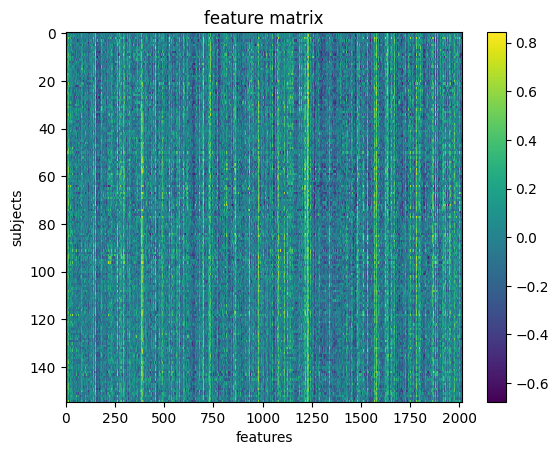

In [15]:
# import matplotlib.pyplot as plt

plt.imshow(X_features, aspect='auto', interpolation='nearest')
plt.colorbar()
plt.title('feature matrix')
plt.xlabel('features')
plt.ylabel('subjects')

### Preparing the data for machine learning

We will split the dataset into a <strong>training set</strong> and a <strong>test set</strong>. The training set will be used to <i>fit the model</i>. The test set will be kept separate and used <i>only at the end</i> to evaluate how well the trained model generalizes to unseen data.

We use a <strong>stratified split</strong> so that the training and test sets have approximately the same proportion of children and adults as the full dataset. Stratification is generally useful for classification tasks because it makes the class distribution more comparable across splits. This is <i>especially important when the classes are imbalanced</i>, since a purely random split could accidentally place too few samples from the minority class in either the training or test set.

Moreover, we set `shuffle=True` to avoid any potential structure contained in row order, e.g., adjacent rows tend to be more similar in age, in gender, handednedd, etc.

In [ ]:
# Split the sample to training/test sets, stratify by age class, and also shuffle the data

assert y_ageclass.shape[0] == X_features.shape[0]

X_train, X_test, y_train, y_test = train_test_split(X_features,                 # x
                                                    y_ageclass,                 # y
                                                    test_size=0.2,              # 80% / 20% split  
                                                    shuffle=True,               # shuffle dataset before splitting
                                                    stratify=y_ageclass,        # keep distribution of ageclass consistent
                                                                                # between train & test sets
                                                    random_state=RANDOM_STATE)  # same shuffle each time

# print the size of our train and test sets
print('train:', len(X_train), '| test:', len(X_test))

train: 124 | test: 31


Let's visualize the class distributions just to be sure (sanity check)!

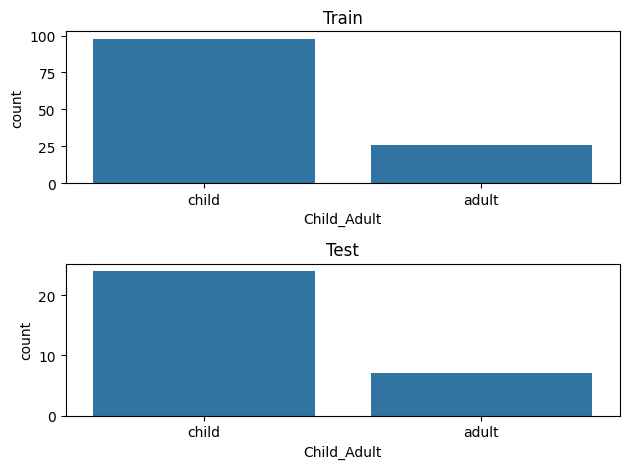

In [17]:
fig,(ax1,ax2) = plt.subplots(2)
sns.countplot(x=y_train, ax=ax1, order=['child','adult'])
ax1.set_title('Train')
sns.countplot(x=y_test, ax=ax2, order=['child','adult'])
ax2.set_title('Test')
plt.tight_layout()

### Run your first model!

We will start with a simple but powerful classifier: a <strong>Support Vector Classifier (SVC)</strong> with a linear kernel. Conceptually, an SVC tries to find a decision boundary that separates the two groups as well as possible. With a <strong>linear kernel</strong>, this boundary is a straight line in 2D, a plane in 3D, or a hyperplane in higher-dimensional feature space. The model chooses the boundary by <i>maximizing the margin</i> between the classes, while allowing some mistakes when the data are not perfectly separable. This makes SVC a useful baseline for high-dimensional neuroimaging data, especially when the sample size is limited and more complex models would be more likely to overfit. As previously mentioned, here we use `class_weight='balanced'` so that the model gives more weight to the minority class if the dataset is imbalanced. This prevents the classifier from simply favoring the larger class.

![](https://docs.opencv.org/2.4/_images/optimal-hyperplane.png)

> For more information on benchmarking functional connectome-based predictive models, you can refer to this [excellent site](https://hal.inria.fr/hal-01824205)!

Anyway... Without further ado, let's fit our first model!

In [18]:
l_svc = SVC(kernel='linear', class_weight='balanced')  # define the model
l_svc.fit(X_train, y_train)                            # fit the model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Well... that was easy. Let's see how well the model learned the data!

We can judge our model on several criteria:
- <strong>Accuracy</strong>: The proportion of predictions that were correct overall
- <strong>Precision</strong>: Accuracy of cases predicted as positive
- <strong>Recall</strong>: Number of true positives correctly predicted to be positive
- <strong>f1 score</strong>: A balance between precision and recall

Or, for a more visual explanation...

![](https://upload.wikimedia.org/wikipedia/commons/2/26/Precisionrecall.svg)

Let's take a look at both the training score and the testing score (the latter is the model's performance on unseen data).
> Since we have more features than samples, this often raises concerns about overfitting -- that is, high training score but substantially worse test score. So we do want to watch out for that!

In [19]:
# get model predcitions on training data
y_pred_train = l_svc.predict(X_train)

# get model training score (defaults to accuracy)
acc_train = l_svc.score(X_train, y_train)
print(f"train score (accuracy) = {acc_train}")

# evaluate model on test set
acc_test = l_svc.score(X_test, y_test)
y_pred_test = l_svc.predict(X_test)
print(f"test score (accuracy) = {acc_test}")

train score (accuracy) = 1.0
test score (accuracy) = 0.967741935483871


Both the training and test accuracies are very high, which does not look like overfitting, at least not on this specific train / test split. But recall that our class labels are imbalanced and accuracy can therefore be inflated by the model mostly predicting the majority class. So we need to look at other evaluation metrics as well.

In [20]:
# get model training precision, recall and f1, all in one convenient report!
cr_train = classification_report(y_true=y_train,
                                 y_pred=y_pred_train)
# get a table to help us break down these scores
cm_train = confusion_matrix(y_true=y_train, 
                            y_pred=y_pred_train,
                            normalize='true')


# same for test set
cr_test = classification_report(y_true=y_test,
                                 y_pred=y_pred_test)
cm_test = confusion_matrix(y_true=y_test,
                           y_pred=y_pred_test,
                           normalize='true')

Let's view our results and plot them all at once by defining a function, so we don't have to repeatedly write the same lines of code every time we train / test the model and needs a classification report and confusion matrix.

TRAIN
              precision    recall  f1-score   support

       adult       1.00      1.00      1.00        26
       child       1.00      1.00      1.00        98

    accuracy                           1.00       124
   macro avg       1.00      1.00      1.00       124
weighted avg       1.00      1.00      1.00       124




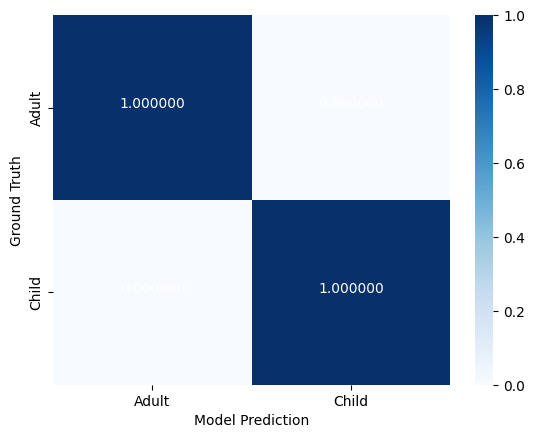

TEST
              precision    recall  f1-score   support

       adult       1.00      0.86      0.92         7
       child       0.96      1.00      0.98        24

    accuracy                           0.97        31
   macro avg       0.98      0.93      0.95        31
weighted avg       0.97      0.97      0.97        31




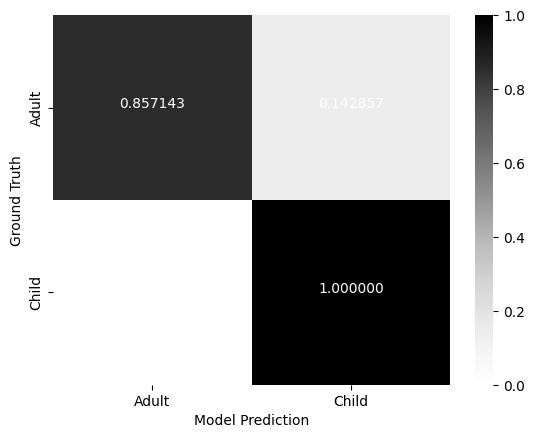

In [21]:
import itertools

def display_results(cr: str, cm: np.ndarray, mode: str, cmap='RdBu_r'):
    print(f'{mode.upper()}\n{cr}\n')  

    cmdf = cmdf = pd.DataFrame(cm, index = ['Adult','Child'], columns = ['Adult','Child'])

    sns.heatmap(cmdf, cmap=cmap)
    plt.xlabel('Model Prediction')
    plt.ylabel('Ground Truth')  

    # label cells in matrix
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j + 0.5, i + 0.5, format(cm[i, j], 'f'),
                 horizontalalignment='center',
                 color='white')
    plt.show()


display_results(cr_train, cm_train, 'train', cmap='Blues')
display_results(cr_test, cm_test, 'test', cmap='Greys')



You can intepret the confusion matrix accroding to this reference graph. But note that confusion matrices can be generalized to multi-class too.

![](https://sebastianraschka.com/images/faq/multiclass-metric/conf_mat.png)

Crucially, our minority class (adult) recall is actually okay (around 0.85, only misclassified 1 subject), meaning the model is not degenerate and always predictingthe majority class. So... so far so good. However, this single test set is just one split, which could be statistically <i>optimistic</i> (or, the other way around, <i>pessimistic</i>). To avoid this "lucky / unlucky" single-split scenario, oftentimes the standard approach is <strong>cross validation (CV)</strong> to get a more stable estimate of model generalization.

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # 5-fold CV

y_train_arr = y_train.to_numpy()
cv_res = cross_validate(SVC(kernel='linear', class_weight='balanced'),
                        X_train,
                        y_train_arr,
                        scoring=['accuracy',
                                 'precision_weighted',
                                 'recall_weighted',
                                 'f1_weighted'],
                         cv=skf,
                         n_jobs=-1,
                         return_train_score=True,
                         return_estimator=True,
                         return_indices=True)

We can look at the model train and validation scores <i>within each CV fold</i>.

In [23]:
train_scores = np.stack([cv_res['train_accuracy'],
                         cv_res['train_precision_weighted'],
                         cv_res['train_recall_weighted'],
                         cv_res['train_f1_weighted']]).T  # shape (n_splits, 4)

valid_scores = np.stack([cv_res['test_accuracy'],
                         cv_res['test_precision_weighted'],
                         cv_res['test_recall_weighted'],
                         cv_res['test_f1_weighted']]).T

for fold, (i, j) in enumerate(zip(train_scores, valid_scores)):
    print(f'\n>> FOLD {fold + 1}')
    data=np.vstack([i, j]).T
    df = pd.DataFrame(data=data,
                      index=['accuracy',
                             'precision_weighted',
                             'recall_weighted',
                             'f1_weighted'],
                      columns=['train', 'valid'])
    print(df)


>> FOLD 1
                    train  valid
accuracy              1.0    1.0
precision_weighted    1.0    1.0
recall_weighted       1.0    1.0
f1_weighted           1.0    1.0

>> FOLD 2
                    train  valid
accuracy              1.0    1.0
precision_weighted    1.0    1.0
recall_weighted       1.0    1.0
f1_weighted           1.0    1.0

>> FOLD 3
                    train     valid
accuracy              1.0  0.960000
precision_weighted    1.0  0.961905
recall_weighted       1.0  0.960000
f1_weighted           1.0  0.958266

>> FOLD 4
                    train     valid
accuracy              1.0  0.880000
precision_weighted    1.0  0.896364
recall_weighted       1.0  0.880000
f1_weighted           1.0  0.864390

>> FOLD 5
                    train  valid
accuracy              1.0    1.0
precision_weighted    1.0    1.0
recall_weighted       1.0    1.0
f1_weighted           1.0    1.0


We can also look at the <i>overall</i> (aggregated) out-of-fold scores of the model.

CV, OVERALL (OUT-OF-FOLD AGGREGATED)
              precision    recall  f1-score   support

       adult       1.00      0.85      0.92        26
       child       0.96      1.00      0.98        98

    accuracy                           0.97       124
   macro avg       0.98      0.92      0.95       124
weighted avg       0.97      0.97      0.97       124




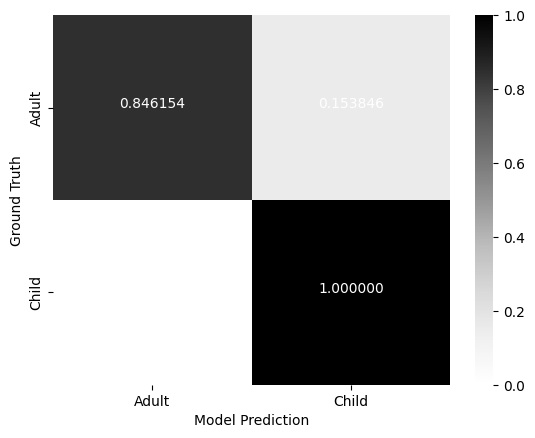

In [24]:
def display_overall_cv_results(cv_results, cmap='RdBu_r'):
    estimators = cv_results['estimator']
    valid_indices = cv_results['indices']['test']

    ground_truths = np.concatenate([y_train_arr[valid_idx]
                                       for valid_idx in valid_indices])
    predictions = np.concatenate([est.predict(X_train[valid_idx])
                                       for est, valid_idx in zip(estimators, valid_indices)])
    overall_cr = classification_report(y_pred=predictions,
                                       y_true=ground_truths)
    overall_cm = confusion_matrix(y_pred=predictions,
                                  y_true=ground_truths,
                                  normalize='true')
    display_results(overall_cr, overall_cm, 'cv, overall (out-of-fold aggregated)', cmap=cmap)

display_overall_cv_results(cv_res, cmap='Greys')


The following cell runs a permutation test to check whether the classifier performs better than we would expect by chance. First, the model is evaluated using the real class labels with cross-validation. Then, the class labels are randomly shuffled many times, and the model is evaluated again on these shuffled-label datasets. If the real cross-validation accuracy is much higher than the accuracies obtained after label shuffling, this suggests that the model is learning a real relationship between the input features and the target labels. The p-value tells us how often the shuffled-label models achieved a score as good as or better than the real model.


In [44]:
score, permutation_scores, pvalue = permutation_test_score(
    l_svc, X_train, y_train, cv=skf, scoring="accuracy",
    n_jobs=-1, n_permutations=100)
print(f'accuracy {score}, average permutation accuracy {permutation_scores.mean()}, p value {pvalue}')

accuracy 0.968, average permutation accuracy 0.7414300000000001, p value 0.009900990099009901


### Standardize the features within cross-validation
After training a first baseline model, we might want to improve the workflow. In machine learning, this can involve trying a different model, <i>tuning hyperparameters</i>, or changing how the input features are preprocessed. However, we must be careful not to use the held-out test set while making these decisions. <strong>The test set should remain genuinely unseen until the final evaluation</strong>; repeatedly checking performance on it would contaminate the evaluation and make the final score no longer independent.

Here, we will focus on one common preprocessing step: <strong>standard scaling</strong>. Standard scaling transforms each feature so that it has mean 0 and unit variance. This is especially relevant for models such as linear SVC, where the learned decision boundary depends on distances, margins, and feature weights. If some features have much larger numerical ranges than others, they can dominate the model simply because of their scale, not because they are more informative.

Importantly, scaling must be performed <strong>inside each cross-validation fold</strong>. The scaler should be fitted only on the training portion of each fold, then applied to that fold's validation data. If we scaled the whole dataset before cross-validation, information from the validation fold would leak into the preprocessing step through the estimated feature means and variances. To prevent this, we wrap the scaler and classifier together in a `Pipeline`, so cross-validation correctly repeats the full preprocessing-and-training workflow within each fold.

In [27]:
# scale the training data WITHIN EACH CV FOLD 
scaler = StandardScaler()
pipe = Pipeline([('standard_scaler', scaler),
                 ('linear_svc', SVC(kernel='linear',
                                    class_weight='balanced'))])

cv_res_scaled = cross_validate(pipe,
                               X_train,
                               y_train_arr,
                               scoring=['accuracy',
                                        'precision_weighted',
                                        'recall_weighted',
                                        'f1_weighted'],
                               cv=skf,
                               n_jobs=-1,
                               return_train_score=True,
                               return_estimator=True,
                               return_indices=True)



Same as before, we grab both the training and validation scores within each fold. But this time, we also check inside our for loop that the train data was indeed scaled to zero-mean and unit-variance by applying `transform()` using each fold's scaler returned from `cross_validate()` -- note that we passed `return_estimator=True`, and here the estimator is a `Pipeline` object, where the first step is `StandardScaling()`.

In [28]:
train_scores = np.stack([cv_res_scaled['train_accuracy'],
                         cv_res_scaled['train_precision_weighted'],
                         cv_res_scaled['train_recall_weighted'],
                         cv_res_scaled['train_f1_weighted']]).T  # shape (n_splits, 4)

valid_scores = np.stack([cv_res_scaled['test_accuracy'],
                         cv_res_scaled['test_precision_weighted'],
                         cv_res_scaled['test_recall_weighted'],
                         cv_res_scaled['test_f1_weighted']]).T

estimators_scaled = cv_res_scaled["estimator"]
train_indices_scaled = cv_res_scaled['indices']['train']

for fold, (i, j, est_scaled, idx) in enumerate(zip(train_scores,
                                            valid_scores,
                                            estimators_scaled,
                                            train_indices_scaled)):
    print(f'\n>> FOLD {fold + 1}')

    s = est_scaled["standard_scaler"]
    x = X_train[idx]
    x_scaled = s.transform(x)
    means, stds = x_scaled.mean(axis=0), x_scaled.std(axis=0)
    print(f'all feature mean close to 0: {np.allclose(means, 0)}')
    print(f'all feature std close to 1:  {np.allclose(stds, 1)}')

    data=np.vstack([i, j]).T
    df = pd.DataFrame(data=data,
                      index=['accuracy',
                             'precision_weighted',
                             'recall_weighted',
                             'f1_weighted'],
                      columns=['train', 'valid'])
    print(df)


>> FOLD 1
all feature mean close to 0: True
all feature std close to 1:  True
                    train  valid
accuracy              1.0    1.0
precision_weighted    1.0    1.0
recall_weighted       1.0    1.0
f1_weighted           1.0    1.0

>> FOLD 2
all feature mean close to 0: True
all feature std close to 1:  True
                    train  valid
accuracy              1.0    1.0
precision_weighted    1.0    1.0
recall_weighted       1.0    1.0
f1_weighted           1.0    1.0

>> FOLD 3
all feature mean close to 0: True
all feature std close to 1:  True
                    train     valid
accuracy              1.0  0.960000
precision_weighted    1.0  0.961905
recall_weighted       1.0  0.960000
f1_weighted           1.0  0.958266

>> FOLD 4
all feature mean close to 0: True
all feature std close to 1:  True
                    train     valid
accuracy              1.0  0.880000
precision_weighted    1.0  0.896364
recall_weighted       1.0  0.880000
f1_weighted           1.0  0.8

CV, OVERALL (OUT-OF-FOLD AGGREGATED)
              precision    recall  f1-score   support

       adult       1.00      0.85      0.92        26
       child       0.96      1.00      0.98        98

    accuracy                           0.97       124
   macro avg       0.98      0.92      0.95       124
weighted avg       0.97      0.97      0.97       124




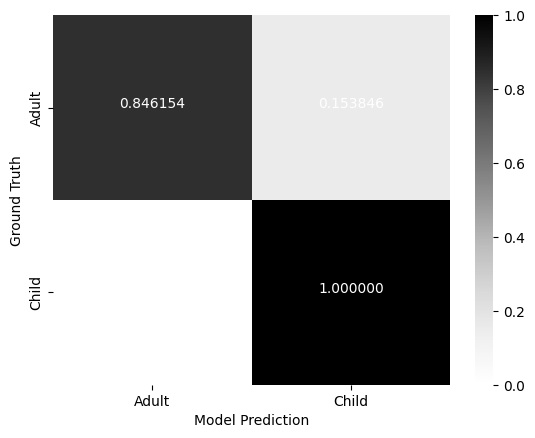

In [29]:
display_overall_cv_results(cv_res_scaled, cmap='Greys')

As we can see, the results (all the scores within each fold, as well as the overall aggregated out-of-fold scores) are <i>exactly identical to wehn we fitted the model on unscaled data</i>! So what's happening here? Has something gone wrong? Let's some some additional checking:

In [30]:
estimators_scaled = cv_res_scaled['estimator']             # actually already defined, but for clarity putting it here again
estimators = cv_res['estimator']                           # same comment as above
train_indices_scaled = cv_res_scaled['indices']['train']   # same comment as above
train_indices = cv_res['indices']['train']
valid_indices_scaled = cv_res_scaled['indices']['test']   # same comment as above
valid_indices = cv_res['indices']['test']
assert all([np.array_equal(i, j) for i, j in zip(train_indices, train_indices_scaled)]) # same skf, fixed random_state, should be equal
assert all([np.array_equal(i, j) for i, j in zip(valid_indices, valid_indices_scaled)])

for fold, (est, est_scaled, train_idx, valid_idx) in enumerate(zip(estimators,
                                                                   estimators_scaled,
                                                                   train_indices,
                                                                   valid_indices)):
    print(f">> FOLD {fold + 1}")

    x_train = X_train[train_idx]
    x_valid = X_train[valid_idx]

    y_hat_train = est.decision_function(x_train)
    pred_train = est.predict(x_train)
    y_hat_train_scaled = est_scaled.decision_function(x_train)
    pred_train_scaled = est_scaled.predict(x_train)

    y_hat_valid = est.decision_function(x_valid)
    pred_valid = est.predict(x_valid)
    y_hat_valid_scaled = est_scaled.decision_function(x_valid)
    pred_valid_scaled = est_scaled.predict(x_valid)
    
    print(f'    Train predictions euqal (scaled vs not scaled): {np.array_equal(pred_train, pred_train_scaled)}')
    print(f'    Train decision functions equal (scaled vs not scaled): {np.array_equal(y_hat_train, y_hat_train_scaled)}')
    print(f'    Valid predictions euqal (scaled vs not scaled): {np.array_equal(pred_valid, pred_valid_scaled)}')
    print(f'    Valid decision functions equal (scaled vs not scaled): {np.array_equal(y_hat_valid, y_hat_valid_scaled)}')
    


>> FOLD 1
    Train predictions euqal (scaled vs not scaled): True
    Train decision functions equal (scaled vs not scaled): False
    Valid predictions euqal (scaled vs not scaled): True
    Valid decision functions equal (scaled vs not scaled): False
>> FOLD 2
    Train predictions euqal (scaled vs not scaled): True
    Train decision functions equal (scaled vs not scaled): False
    Valid predictions euqal (scaled vs not scaled): True
    Valid decision functions equal (scaled vs not scaled): False
>> FOLD 3
    Train predictions euqal (scaled vs not scaled): True
    Train decision functions equal (scaled vs not scaled): False
    Valid predictions euqal (scaled vs not scaled): True
    Valid decision functions equal (scaled vs not scaled): False
>> FOLD 4
    Train predictions euqal (scaled vs not scaled): True
    Train decision functions equal (scaled vs not scaled): False
    Valid predictions euqal (scaled vs not scaled): True
    Valid decision functions equal (scaled vs not

The scaled and unscaled models make the <strong>same final predictions</strong> in this example: each participant is assigned to the same class label, such as `child` or `adult`. However, this does <strong>not</strong> mean the models are exactly the same. The predicted label is only the final output after the model has made its decision. Before that, the model computes a continuous decision score using `decision_function`. This score reflects how strongly the model places a sample on one side of the decision boundary. Here, the class labels are identical after scaling, but the decision-function values are not. This means scaling <i>did</i> change the internal model scores, even though it did not change the final predicted categories.


### Refit the final pipeline and evaluate on the test set
After using cross-validation on the <strong>training set only</strong>, the standard workflow is to choose a final modeling pipeline. This may include the model type, preprocessing steps, and, in many real analyses, selected hyperparameters. Once that decision is made, we refit the entire finalized pipeline on the <strong>full training set</strong>, so the model can learn from all available training data. Only then do we evaluate it once on the held-out <strong>test set</strong>, which has not been used for model selection or workflow decisions. In this tutorial, we did <strong>NOT</strong> perform hyperparameter tuning; we only compared the baseline workflow with a version that adds standard scaling inside a pipeline. We will now refit that chosen pipeline on the full training data and use the test set for the final evaluation.


TEST
              precision    recall  f1-score   support

       adult       1.00      0.86      0.92         7
       child       0.96      1.00      0.98        24

    accuracy                           0.97        31
   macro avg       0.98      0.93      0.95        31
weighted avg       0.97      0.97      0.97        31




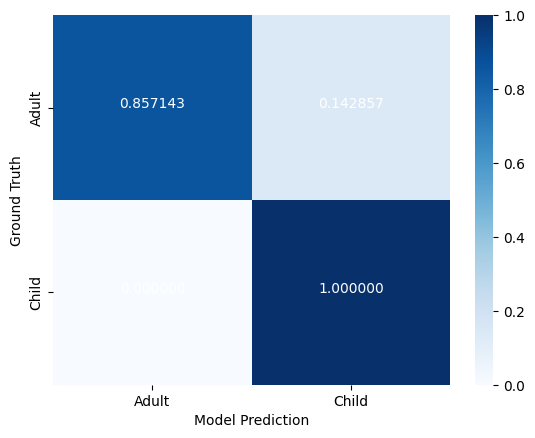

In [41]:
# Re-instantiate Pipeline for clarity and to guarntee fresh refit of both scaler and SVC
pipe = Pipeline([('standard_scaler', scaler),
                 ('linear_svc', SVC(kernel='linear',
                                    class_weight='balanced'))])
pipe.fit(X_train, y_train)

# Evaluate model on test set
y_pred_test = pipe.predict(X_test)

# And actually, the above is equivalent to doing:
'''scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

l_svc.fit(X_train_scaled, y_train)
y_pred_test = l_svc.predict(X_test_scaled)'''


cr_test_scaled = classification_report(y_true=y_test,
                                       y_pred=y_pred_test)
cm_test_scaled = confusion_matrix(y_true=y_test,
                                  y_pred=y_pred_test,
                                  normalize='true')

display_results(cr_test_scaled, cm_test_scaled, 'test', 'Blues')

## Model weights

For a linear SVC, the learned coefficients define the orientation of the separating hyperplane: they tell us how each feature contributes to the model’s decision function after preprocessing and scaling. However, these coefficients should not be treated as straightforward “feature importances.” Their values depend on feature scaling, correlations among features, preprocessing choices, regularization strength, and the geometry of the training data. A large coefficient means that changing that feature, while holding the others fixed in the transformed feature space, has a larger effect on the decision score; it does not necessarily mean that the feature is biologically or causally important. For non-linear SVCs, this interpretation becomes even less direct because the decision boundary is defined through kernel similarities rather than explicit feature weights in the original input space. So, we can inspect the model weights as a rough diagnostic of what the classifier used, but any substantive interpretation requires caution and additional validation.

We can access the weights used by the model via the `.coef_` attribute:

In [42]:
print(l_svc.coef_)

[[ 0.00233769  0.00272561 -0.00238193 ... -0.00327216 -0.00188801
  -0.00161691]]


Let's plot these weights to see their distribution better:

Text(0, 0.5, 'weight')

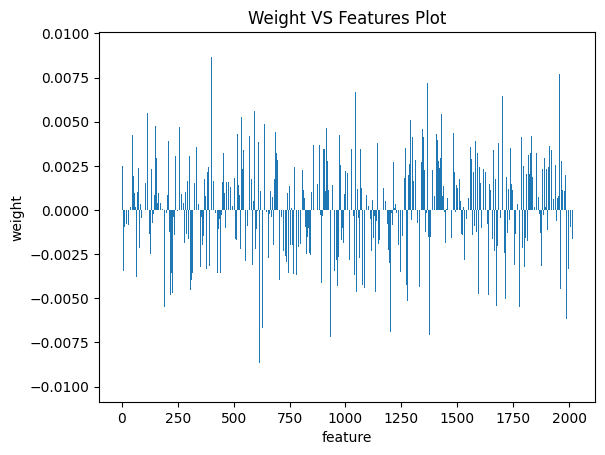

In [43]:
plt.bar(range(l_svc.coef_.shape[-1]),l_svc.coef_[0])
plt.title('Weight VS Features Plot')
plt.xlabel('feature')
plt.ylabel('weight')

Or perhaps it will be easier to visualize this information as a matrix similar to the one we started with

We can use the correlation measure from before to perform an inverse transform

In [46]:
correlation_measure.inverse_transform(l_svc.coef_).shape

(1, 64, 64)

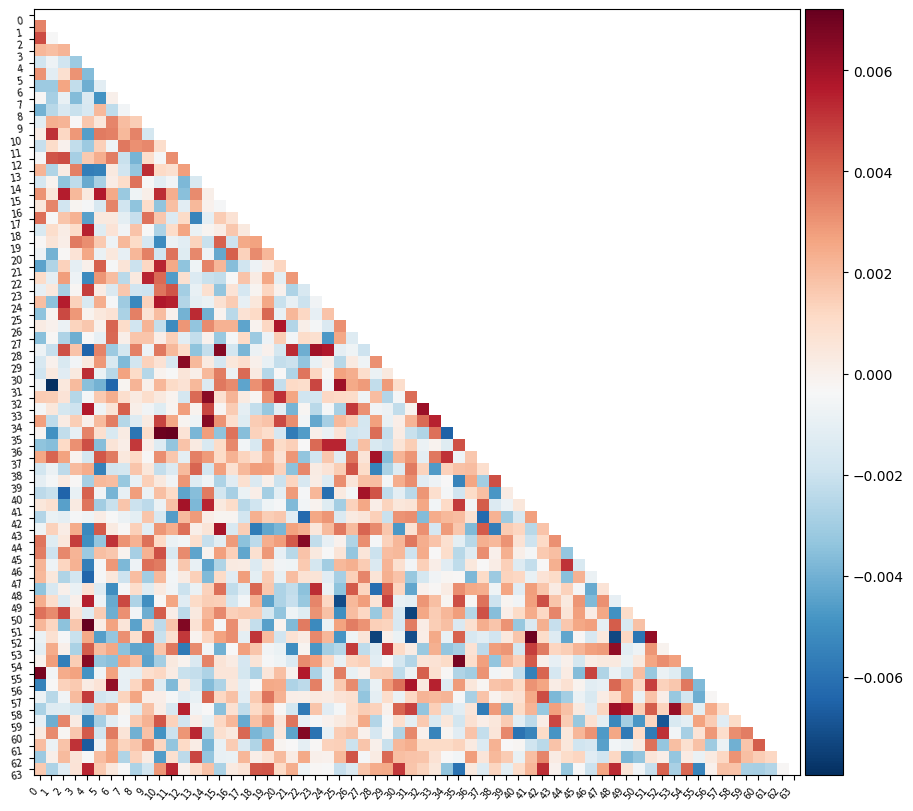

In [47]:
from nilearn import plotting

feat_exp_matrix = correlation_measure.inverse_transform(l_svc.coef_)[0]

plotting.plot_matrix(feat_exp_matrix, figure=(10, 8),  
                     labels=range(feat_exp_matrix.shape[0]),
                     reorder=False,
                    tri='lower')

Let's see if we can throw those features onto an actual brain.

First, we'll need to gather the coordinates of each ROI of our atlas

In [48]:
coords = plotting.find_parcellation_cut_coords(atlas_filename)

And now we can use our feature matrix and the wonders of nilearn to create a connectome map where each node is an ROI, and each connection is weighted by the importance of the feature to the model

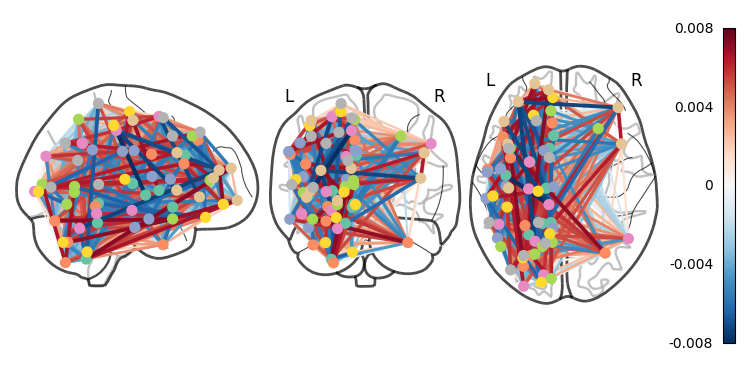

In [49]:
plotting.plot_connectome(feat_exp_matrix, coords, colorbar=True)

Whoa!! That's...a lot to process. Maybe let's threshold the edges so that only the most important connections are visualized

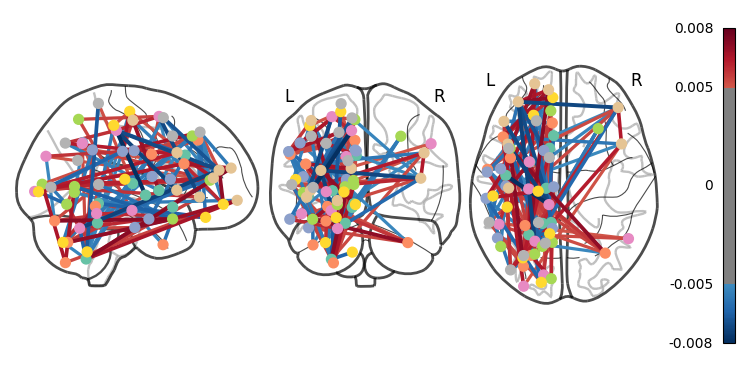

In [50]:
plotting.plot_connectome(feat_exp_matrix, coords, colorbar=True, edge_threshold=0.005)

That's definitely an improvement, but it's still a bit hard to see what's going on.
Nilearn has a new feature that lets us view this data interactively!

In [51]:
plotting.view_connectome(feat_exp_matrix, coords, edge_threshold='90%')

You can choose to open the figure in a browser with the following lines:

In [ ]:
# view = plotting.view_connectome(feat_exp_matrix, coords, edge_threshold='90%')
# view.open_in_browser()

## Exercises

1. We walked through a lot of mistakes in this tutorial, try to start a fresh notebook and create a clean, and correct version of the workflow.
2. The dataset contains the exact age of the subjects. Try to predict the age of the subjects instead of the age class. Hint - use regression instead of classification.
3. Try other atlases - does a different atlas change the results?
4. Advanced - try to implement different atlases as part of the [parameter tuning](https://scikit-learn.org/stable/modules/grid_search.html).